# Bayesian Estimation of Credit Default

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, RocCurveDisplay

# load cleaned data
df = pd.read_csv('../data/processed/cleaned_default_data.csv')
df.columns = df.columns.str.strip()

# use all 23 features, standardized (same as Patrick's MLE notebook)
target = 'default payment next month'
feature_cols = [col for col in df.columns if col != target]

scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols].values)
y = df[target].values

print(f"dataset size:   {len(df)} observations")
print(f"num features:   {X.shape[1]}")
print(f"defaults:       {y.sum()} ({y.mean()*100:.1f}%)")

dataset size:   29965 observations
num features:   23
defaults:       6630 (22.1%)


## Bayesian Mathematical Methodology

Instead of finding one single best $\boldsymbol{\beta}$ like Maximum Likelihood Estimation does, Bayesian estimation gives us a **full probability distribution** over $\boldsymbol{\beta}$, which shows us which values are plausible and how confident we are in each one.

This approach is grounded in **Bayes' Theorem**:

$$P(\boldsymbol{\beta} \mid \text{data}) \propto P(\text{data} \mid \boldsymbol{\beta}) \cdot P(\boldsymbol{\beta})$$

Each term plays a distinct role in this framework:
- $P(\boldsymbol{\beta})$ is the **prior**, representing our belief about $\boldsymbol{\beta}$ before seeing any data
- $P(\text{data} \mid \boldsymbol{\beta})$ is the **likelihood**, measuring how well a given $\boldsymbol{\beta}$ explains the observed data (this is the same logistic regression likelihood from Patrick's notebook)
- $P(\boldsymbol{\beta} \mid \text{data})$ is the **posterior**, which is our updated belief about $\boldsymbol{\beta}$ after combining the prior with the data

Since we have 23 features, grid search is not feasible as it would require evaluating a 23-dimensional grid. Instead, we use the **Laplace approximation**: we find the peak of the posterior (the MAP estimate), then approximate the full posterior as a multivariate Normal distribution centered at that peak.

## Prior Specification

Before computing the posterior distribution, we need to define our **prior**, that is, what do we believe about $\boldsymbol{\beta}$ before looking at any data?

Since there is no strong reason nor evidence to think that any feature can increase or decrease default risk ahead of time, we place an independent Normal prior on each coefficient. This gives us a **multivariate weakly informative prior**:

$$P(\boldsymbol{\beta}) = \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}), \quad \sigma = 10$$

This is equivalent to saying each $\beta_j$ individually follows $\mathcal{N}(0, 10)$, centered at zero with a wide spread. Since we have over 30,000 observations, the likelihood will dominate and the posterior will almost be entirely driven by data, rather than by our prior initialization.

## Likelihood Function

With the prior defined, we need to define the **likelihood**, which tells us how probable our observed data is given a particular value of $\boldsymbol{\beta}$. 

For a single observation, the probability of default is:

$$P(Y = 1 \mid \mathbf{x}) = \sigma(\mathbf{x}^T \boldsymbol{\beta}) = \frac{1}{1 + e^{-\mathbf{x}^T \boldsymbol{\beta}}}$$

Extending this across all $n$ observations and taking the log to avoid numerical underflow:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log \sigma(\mathbf{x}_i^T \boldsymbol{\beta}) + (1 - y_i) \log(1 - \sigma(\mathbf{x}_i^T \boldsymbol{\beta})) \right]$$

In [ ]:
def log_likelihood(beta, X, y):
    # predicted probabilities for all observations
    probs = expit(X @ beta)
    return np.sum(y * np.log(probs) + (1 - y) * np.log(1 - probs))

def log_prior(beta, prior_std=10):
    # independent normal(0, 10) on each coefficient
    return -0.5 * np.sum((beta / prior_std) ** 2)

def log_posterior(beta, X, y):
    return log_likelihood(beta, X, y) + log_prior(beta)

functions defined: log_likelihood, log_prior, log_posterior


## Laplace Approximation

Since grid search over 23 features is computationally impossible, the alternative is to use the Laplace approximation:

**1. Find the peak of the posterior.**

The peak is the single value of $\boldsymbol{\beta}$ that best combines the likelihood and the prior. This is called the MAP estimate, and it is found by solving:

$$\hat{\boldsymbol{\beta}}_{MAP} = \arg\max_{\boldsymbol{\beta}} \left[ \ell(\boldsymbol{\beta}) + \log P(\boldsymbol{\beta}) \right]$$

**2. Approximate the shape of the posterior around that peak.**

Rather than drawing out the full posterior shape, we describe it using the curvature at the peak. A steeper, sharper peak means the posterior is narrow and that we are confident in $\boldsymbol{\beta}$. A flatter peak means more uncertainty. This curvature is captured by the **Hessian** $\mathbf{H}$, which for logistic regression with a Normal prior has the closed form:

$$\mathbf{H} = \mathbf{X}^T \text{diag}\left(\hat{p}_i (1 - \hat{p}_i)\right) \mathbf{X} + \frac{1}{\sigma^2} \mathbf{I}$$

where $\hat{p}_i = \sigma(\mathbf{x}_i^T \hat{\boldsymbol{\beta}}_{MAP})$ is the predicted default probability for each observation. The full posterior is then approximated as:

$$P(\boldsymbol{\beta} \mid \text{data}) \approx \mathcal{N}\left(\hat{\boldsymbol{\beta}}_{MAP},\ \mathbf{H}^{-1}\right)$$

In [9]:
prior_std = 10

# find MAP estimate by minimizing negative log-posterior
result = minimize(
    fun=lambda b: -log_posterior(b, X, y),
    x0=np.zeros(X.shape[1]),
    method='L-BFGS-B'
)
beta_map = result.x

# compute hessian at MAP using closed-form expression
p_hat = expit(X @ beta_map)
W = p_hat * (1 - p_hat)
H = (X.T * W) @ X + (1 / prior_std**2) * np.eye(X.shape[1])

# posterior covariance is the inverse of the hessian
post_cov = np.linalg.inv(H)
post_std = np.sqrt(np.diag(post_cov))
print(f"top feature by MAP: {feature_cols[np.argmax(np.abs(beta_map))]} = {beta_map[np.argmax(np.abs(beta_map))]:.4f}")

top feature by MAP: PAY_0 = 0.4942


## Credible Intervals
With the posterior distribution, we can extract a 95% credible interval for each coefficient. This tells us the range of values that $\beta_j$ most reasonably is given the data, with a 95% probability guarantee.

Since the posterior is a Normal distribution, the interval for each coefficient is the MAP estimate plus or minus 1.96 standard deviations, where the standard deviation comes from the diagonal of the posterior covariance matrix $\mathbf{H}^{-1}$:

$$\left[\hat{\beta}_{j} - 1.96 \cdot \sqrt{\Sigma_{jj}},\ \hat{\beta}_{j} + 1.96 \cdot \sqrt{\Sigma_{jj}}\right]$$

Any coefficient whose interval does not cross zero has a credibly non-zero effect on default probability.

  feature     MAP  CI lower  CI upper  post std
    PAY_0  0.4942    0.4599    0.5285    0.0175
BILL_AMT1 -0.2168   -0.3112   -0.1223    0.0482
    PAY_2  0.1141    0.0714    0.1568    0.0218
    PAY_3  0.0662    0.0206    0.1119    0.0233
 PAY_AMT1 -0.0647   -0.0993   -0.0300    0.0177
      AGE  0.0591    0.0323    0.0860    0.0137
 MARRIAGE -0.0541   -0.0804   -0.0278    0.0134
EDUCATION -0.0537   -0.0789   -0.0284    0.0129
 PAY_AMT2 -0.0445   -0.0884   -0.0006    0.0224
BILL_AMT2  0.0373   -0.0909    0.1654    0.0654
LIMIT_BAL -0.0343   -0.0641   -0.0045    0.0152
    PAY_5  0.0330   -0.0189    0.0849    0.0265
      SEX -0.0309   -0.0549   -0.0069    0.0122
BILL_AMT3  0.0267   -0.0921    0.1456    0.0606
    PAY_4  0.0254   -0.0240    0.0748    0.0252
 PAY_AMT4 -0.0210   -0.0531    0.0111    0.0164
 PAY_AMT5 -0.0188   -0.0512    0.0137    0.0166
BILL_AMT6  0.0143   -0.0800    0.1085    0.0481
BILL_AMT4 -0.0130   -0.1253    0.0992    0.0573
 PAY_AMT3 -0.0090   -0.0431    0.0251   

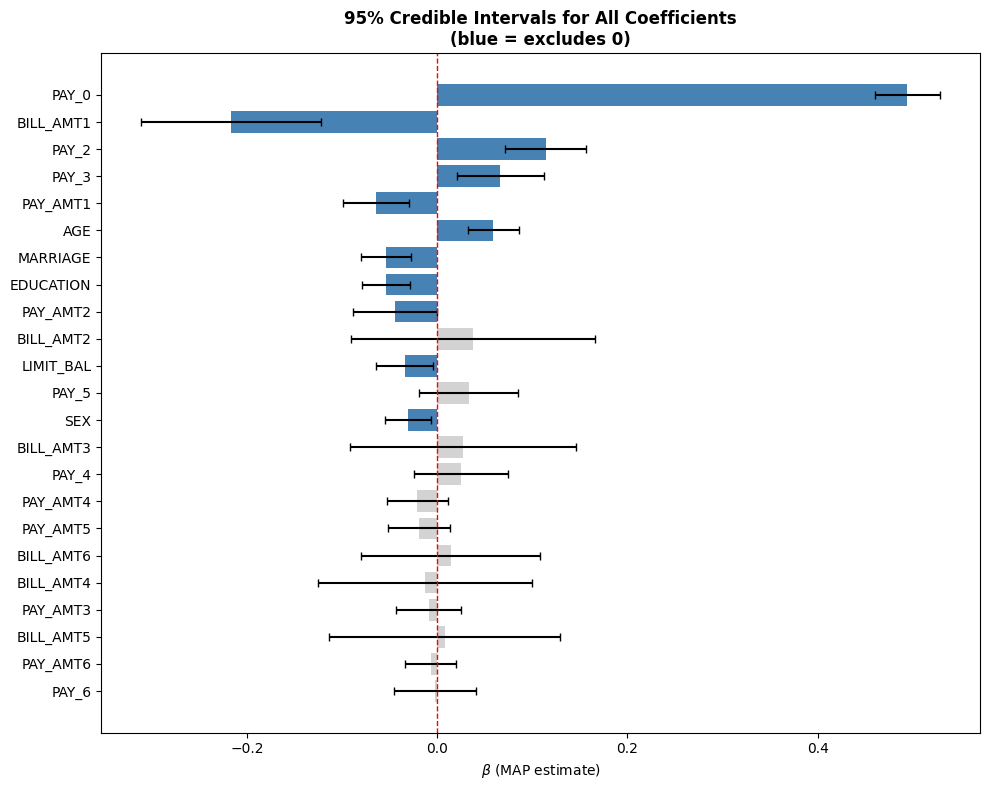

In [4]:
# compute 95% credible intervals for all 23 coefficients
ci_lower = beta_map - 1.96 * post_std
ci_upper = beta_map + 1.96 * post_std

# build summary table sorted by absolute MAP value
results_df = pd.DataFrame({
    'feature':  feature_cols,
    'MAP':      beta_map,
    'CI lower': ci_lower,
    'CI upper': ci_upper,
    'post std': post_std
}).sort_values('MAP', key=abs, ascending=False)

print(results_df.to_string(index=False, float_format='{:.4f}'.format))

# plot credible intervals for all features
fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(feature_cols))
order = np.argsort(np.abs(beta_map))

ax.barh(y_pos, beta_map[order], xerr=1.96 * post_std[order],
        color=['steelblue' if ci_lower[i] * ci_upper[i] > 0 else 'lightgray'
               for i in order],
        align='center', capsize=3)
ax.axvline(0, color='red', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels([feature_cols[i] for i in order])
ax.set_xlabel('$\\beta$ (MAP estimate)')
ax.set_title('95% Credible Intervals for All Coefficients\n(blue = excludes 0)', weight='bold')
plt.tight_layout()
plt.show()

$$Figure: Credible \ Interval$$
- from the figure above, we could tell that `PAY_0` is the strongest positive effect, meaning people who did not pay (the most recent month) would have a higher likelihood of defaulting
- `BILL_AMT1` has a strong negative effect, meaning higher recent bill lowers default risk
- other payment month variables are less significant, suggesting that payment information from distant times are no longer that significant or predictive of the credit default risk outcome

### Plotting the bell curves for each individual predictors

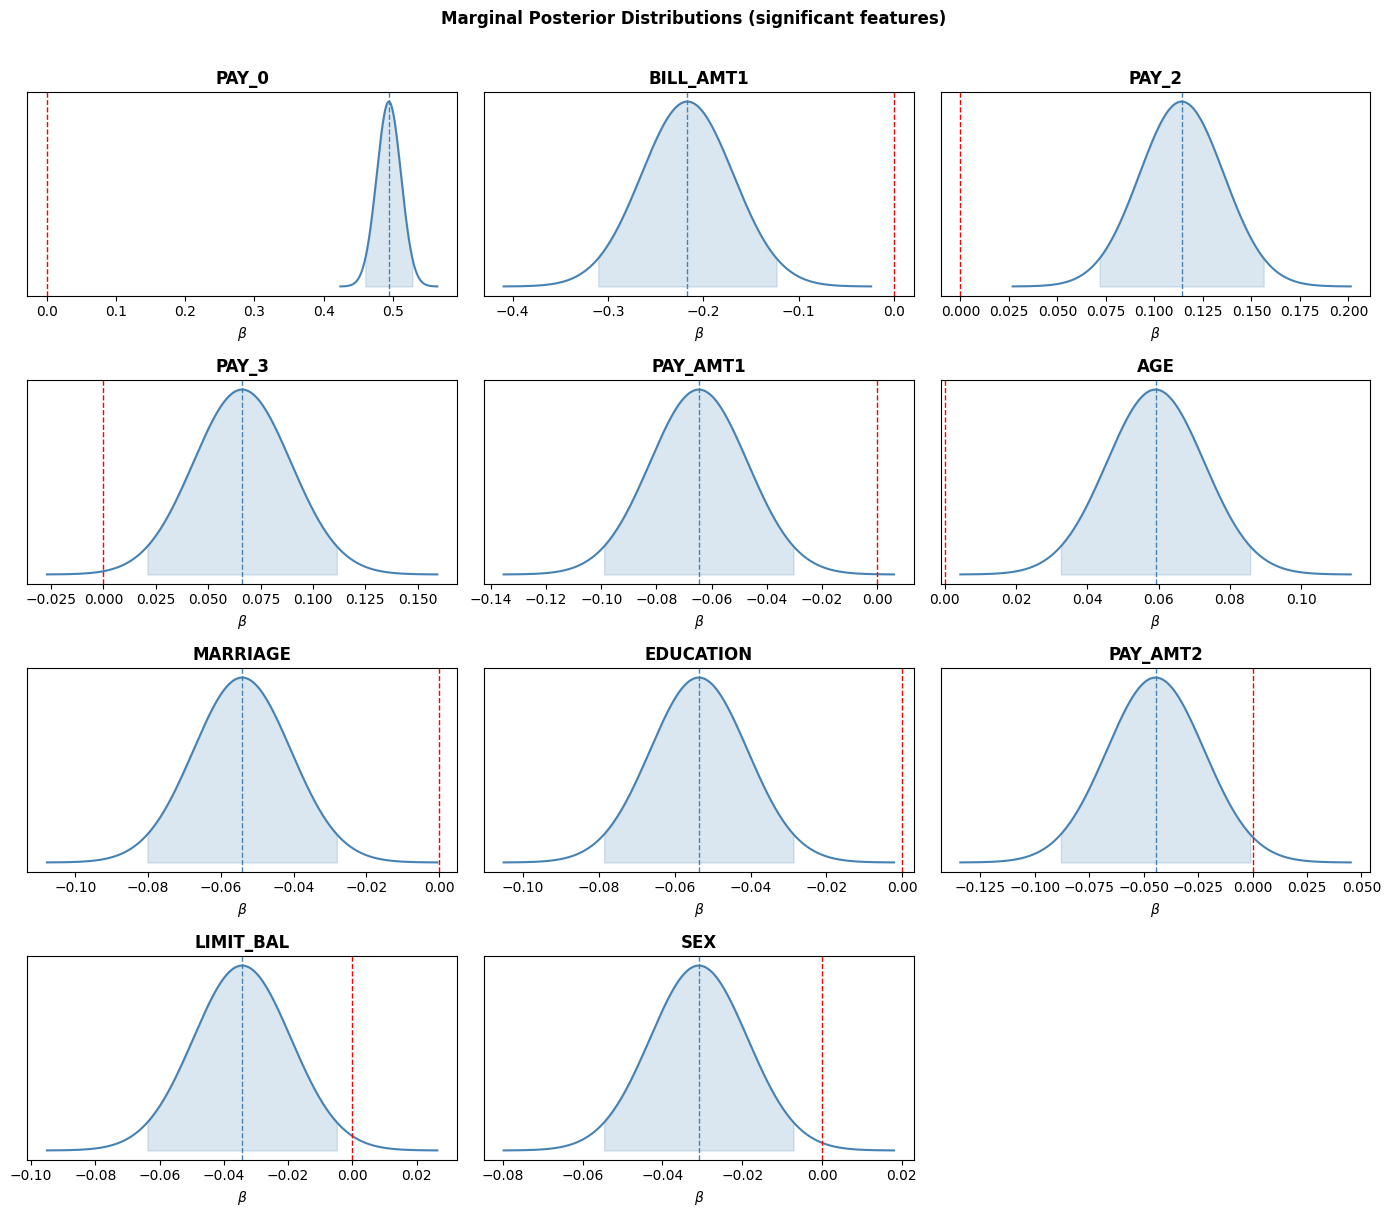

In [ ]:
# plot marginal posterior distributions for significant features only
significant = [i for i in range(len(feature_cols)) if ci_lower[i] * ci_upper[i] > 0]
significant = sorted(significant, key=lambda i: abs(beta_map[i]), reverse=True)

n_cols = 3
n_rows = -(-len(significant) // n_cols)  # ceiling division to get number of rows needed
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for idx, i in enumerate(significant):
    ax = axes[idx]
    x = np.linspace(beta_map[i] - 4 * post_std[i], beta_map[i] + 4 * post_std[i], 300)
    density = norm.pdf(x, beta_map[i], post_std[i])
    ax.plot(x, density, color='steelblue')
    ax.fill_between(x, density, where=(x >= ci_lower[i]) & (x <= ci_upper[i]), color='steelblue', alpha=0.2, label='95% CI')
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.axvline(beta_map[i], color='steelblue', linestyle='--', linewidth=1)
    ax.set_title(feature_cols[i], weight='bold')
    ax.set_xlabel('$\\beta$')
    ax.set_yticks([])

# hide unused subplots
for j in range(len(significant), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Marginal Posterior Distributions (significant features)', weight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Posterior Prediction

accuracy: 0.6002
recall: 0.7087
auc: 0.7181


/home/ethancao/Credit-Default-Inference-Prediction/venv/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


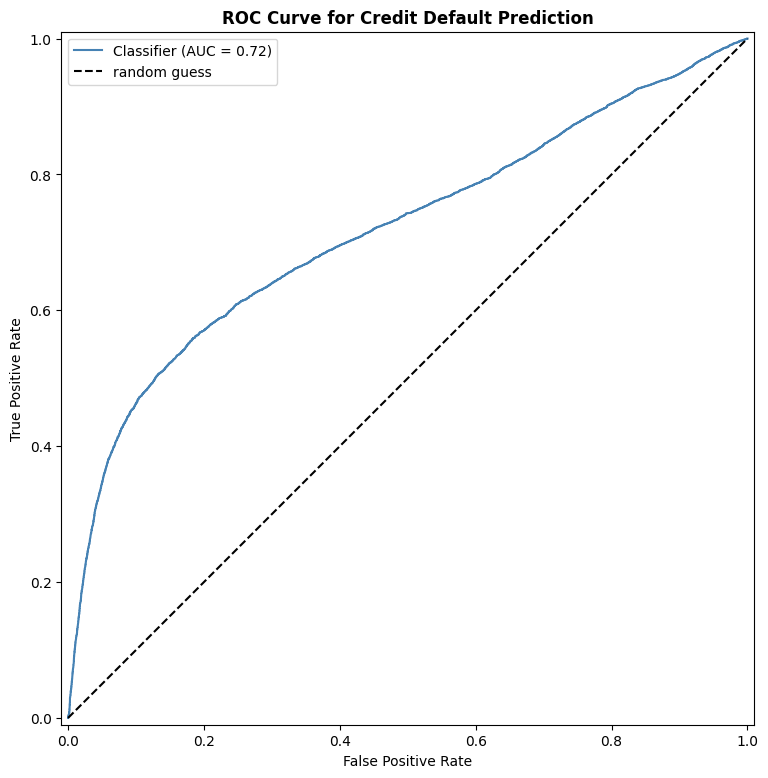

In [8]:
# predict using MAP estimate
p_pred = expit(X @ beta_map)
y_pred = (p_pred >= 0.5).astype(int)

accuracy = accuracy_score(y, y_pred)
recall = recall_score(y, y_pred)
auc = roc_auc_score(y, p_pred)

print(f"accuracy: {accuracy:.4f}")
print(f"recall: {recall:.4f}")
print(f"auc: {auc:.4f}")

# ROC curve
fig, ax = plt.subplots(figsize=(9, 9))
RocCurveDisplay.from_predictions(y, p_pred, ax=ax, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', label='random guess')
ax.set_title('ROC Curve for Credit Default Prediction', weight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.show()